<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo.png" align="left" width=300></p></td><td><font size=3><B>Lecture 11 实验 （郑海超）</B></font></td></tr></table>

# 中国股市存在月度效应吗？基于上证指数月度数据的实证分析

**提交作业：**
- 在线提交：http://swufe.fanya.chaoxing.com/portal
- 截止日期：2025年12月11日晚上8点
- 仅仅提交**这个jupyter文档**，命名为“lecture11_experiment_学号_姓名.ipynb”，其中学号和姓名请替换为你自己的学号和姓名。


**下周我们邀请同学分享其完成作业的结果和过程经验总结**

研究假设：
- H₀: 中国股市不存在显著月度效应（每个月的收益率没有显著差异）
- H₁: 中国股市存在显著月度效应（每个月的收益率存在显著差异）


工作步骤：
- 读取中国上证指数的月线行情数据（我已经从tushare下载了上证指数的月线行情数据）
- 计算月度收益率（使用对数收益率：$R_{t} = \log(P_{t}) - \log(P_{t-1})$），示例代码如下：
  ```python
  df['log_return'] = np.log(df[price_col] / df[price_col].shift(1))
  ```
- 月度收益率的分布特征统计描述
- 月度收益率的可视化展示
- 统计显著性检验（例如，t检验、ANOVA、回归分析等）
- 异质性分析：不同历史时期都存在月度效应吗
- 解释统计结果，判断是否拒绝H₀，以及可能的原因
- 总结作业过程遇到的困难以及解决经验



可能使用的工具和知识点：
- tushare库（用于下载股票数据）
- pandas库和numpy库（用于数据处理和分析）
- matplotlib库（用于数据可视化）
- scipy库（用于统计分析） - from scipy import stats

更多pandas相关资料：
- https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html

更多stats相关资料：
- https://docs.scipy.org/doc/scipy/reference/stats.html
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html#scipy.stats.f_oneway

# 读取中国上证指数的月线行情数据

In [2]:
# 读取中国上证指数的月线行情数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv('index_sh.csv')

# 查看数据前几行和基本信息
print("数据前5行：")
print(df.head())
print("\n数据基本信息：")
print(df.info())
print("\n数据统计描述：")
print(df.describe())

数据前5行：
     ts_code  trade_date      close       open       high        low  \
0  000001.SH    20250820  3766.2104  3716.6847  3767.4300  3704.9912   
1  000001.SH    20250819  3727.2879  3728.4851  3746.6690  3718.1467   
2  000001.SH    20250818  3728.0273  3712.4952  3745.9390  3702.3802   
3  000001.SH    20250815  3696.7705  3659.8146  3702.2553  3658.3762   
4  000001.SH    20250814  3666.4426  3685.5223  3704.7715  3662.5695   

   pre_close   change  pct_chg          vol        amount  
0  3727.2879  38.9225   1.0443  679836426.0  1.017500e+09  
1  3728.0273  -0.7394  -0.0198  696099750.0  1.060899e+09  
2  3696.7705  31.2568   0.8455  776016669.0  1.133942e+09  
3  3666.4426  30.3279   0.8272  678521703.0  9.606250e+08  
4  3683.4648 -17.0222  -0.4621  647829587.0  9.494643e+08  

数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6212 entries, 0 to 6211
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0

# 计算月度收益率

In [3]:
# 计算月度收益率

# 将交易日期转换为日期类型
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')

# 设置日期为索引
df.set_index('trade_date', inplace=True)

# 按月份重采样，取每月最后一个交易日的数据
monthly_data = df.resample('M').last()

# 计算对数收益率
monthly_data['log_return'] = np.log(monthly_data['close'] / monthly_data['close'].shift(1))

# 移除第一行缺失值
monthly_data.dropna(inplace=True)

# 添加月份列
monthly_data['month'] = monthly_data.index.month

print("月度数据前5行：")
print(monthly_data.head())
print("\n月度数据基本信息：")
print(monthly_data.info())

月度数据前5行：
              ts_code     close      open      high       low  pre_close  \
trade_date                                                                 
2000-02-29  000001.SH  1714.578  1728.136  1733.141  1678.350   1704.855   
2000-03-31  000001.SH  1800.225  1810.553  1810.897  1780.411   1810.984   
2000-04-30  000001.SH  1836.321  1805.503  1836.329  1797.713   1806.830   
2000-05-31  000001.SH  1894.554  1875.463  1894.583  1869.338   1877.471   
2000-06-30  000001.SH  1928.106  1937.843  1941.402  1924.969   1937.261   

            change  pct_chg         vol        amount  log_return  month  
trade_date                                                                
2000-02-29   9.723   0.5703  28680757.0  3.219601e+07    0.110639      2  
2000-03-31 -10.759  -0.5941  23340725.0  1.855225e+07    0.048745      3  
2000-04-30  29.491   1.6322  10971311.0  1.136810e+07    0.019852      4  
2000-05-31  17.083   0.9099  15769235.0  1.624771e+07    0.031219      5  
2000-06-

C:\Users\Nanzheng\AppData\Local\Temp\ipykernel_50284\1312243182.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample('M').last()


# 月度收益率的分布特征统计描述

In [4]:
# 月度收益率的分布特征统计描述

# 总体统计描述
print("月度收益率总体统计描述：")
print(monthly_data['log_return'].describe())

# 按月份统计描述
print("\n各月份收益率统计描述：")
monthly_stats = monthly_data.groupby('month')['log_return'].describe()
print(monthly_stats)

# 计算各月份的平均收益率和标准差
monthly_mean = monthly_data.groupby('month')['log_return'].mean()
monthly_std = monthly_data.groupby('month')['log_return'].std()

print("\n各月份平均收益率：")
print(monthly_mean)
print("\n各月份收益率标准差：")
print(monthly_std)

月度收益率总体统计描述：
count    307.000000
mean       0.002924
std        0.070007
min       -0.282783
25%       -0.036743
50%        0.004461
75%        0.040806
max        0.242528
Name: log_return, dtype: float64

各月份收益率统计描述：
       count      mean       std       min       25%       50%       75%  \
month                                                                      
1       25.0 -0.013026  0.084528 -0.256814 -0.060770 -0.003803  0.049980   
2       26.0  0.025682  0.045105 -0.065726  0.007354  0.023853  0.043995   
3       26.0  0.005375  0.076250 -0.224905 -0.025953  0.001948  0.049448   
4       26.0  0.014978  0.064345 -0.087576 -0.020681  0.002232  0.039115   
5       26.0  0.000280  0.056871 -0.102038 -0.033577  0.000790  0.042309   
6       26.0 -0.017318  0.077927 -0.227003 -0.070649  0.003073  0.022606   
7       26.0  0.006018  0.072702 -0.154823 -0.032685  0.004641  0.034382   
8       26.0 -0.015018  0.077179 -0.246083 -0.043884 -0.008495  0.027667   
9       25.0  0.00066

# 月度收益率的可视化分析

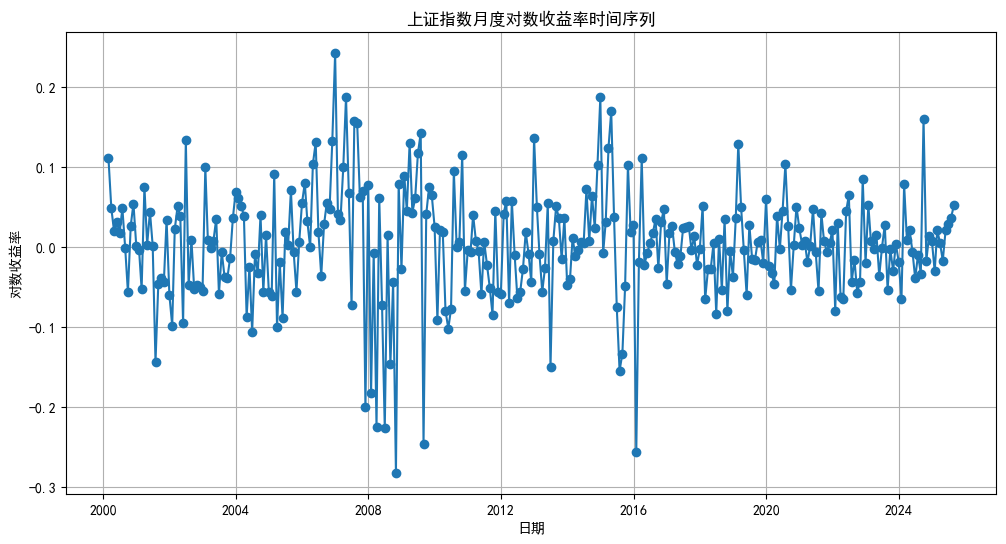

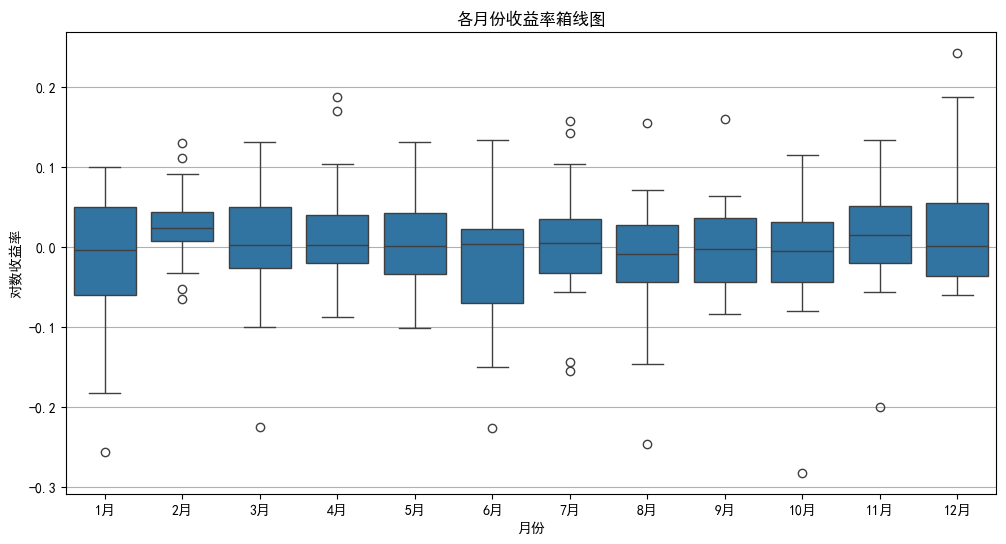

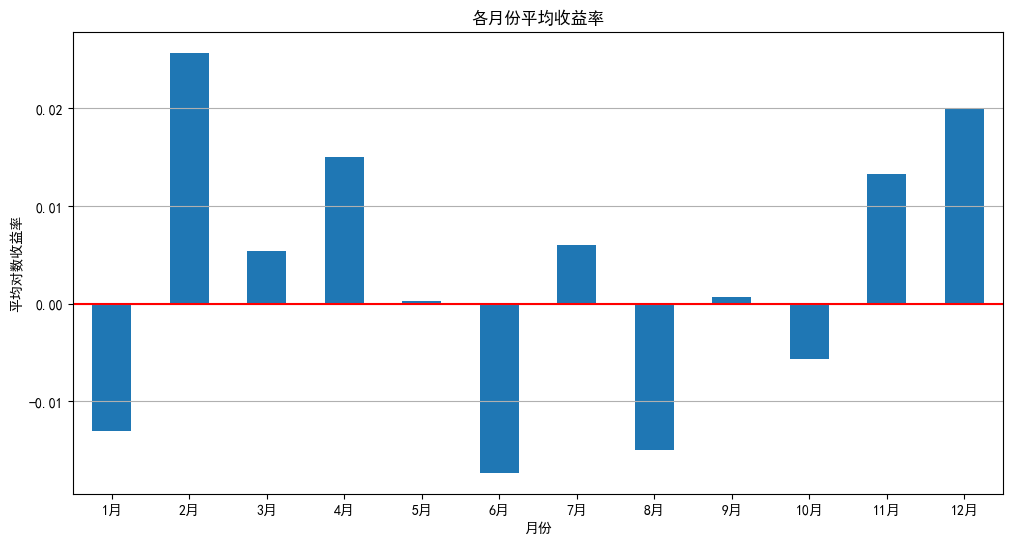

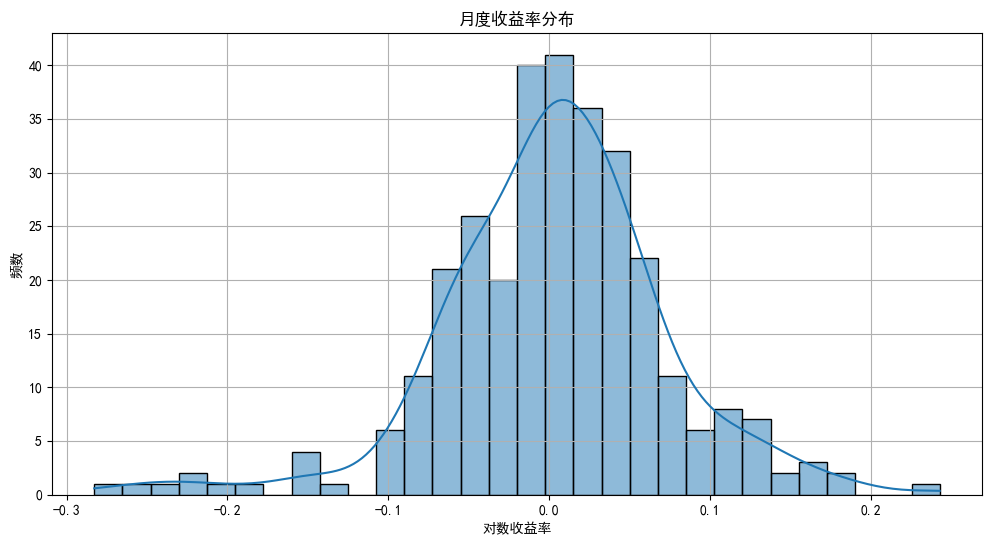

In [5]:
# 月度收益率的可视化分析

# 1. 月度收益率时间序列图
plt.figure(figsize=(12, 6))
plt.plot(monthly_data.index, monthly_data['log_return'], marker='o', linestyle='-')
plt.title('上证指数月度对数收益率时间序列')
plt.xlabel('日期')
plt.ylabel('对数收益率')
plt.grid(True)
plt.show()

# 2. 各月份收益率箱线图
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='log_return', data=monthly_data)
plt.title('各月份收益率箱线图')
plt.xlabel('月份')
plt.ylabel('对数收益率')
plt.xticks(range(12), ['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月'])
plt.grid(True, axis='y')
plt.show()

# 3. 各月份平均收益率柱状图
plt.figure(figsize=(12, 6))
monthly_mean.plot(kind='bar')
plt.title('各月份平均收益率')
plt.xlabel('月份')
plt.ylabel('平均对数收益率')
plt.xticks(range(12), ['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月'], rotation=0)
plt.grid(True, axis='y')
plt.axhline(y=0, color='r', linestyle='-')
plt.show()

# 4. 月度收益率分布图
plt.figure(figsize=(12, 6))
sns.histplot(monthly_data['log_return'], bins=30, kde=True)
plt.title('月度收益率分布')
plt.xlabel('对数收益率')
plt.ylabel('频数')
plt.grid(True)
plt.show()

# 统计显著性检验（这个不强制要求）

In [6]:
# 统计显著性检验

# 1. ANOVA检验：检验各月份收益率是否存在显著差异
months = [monthly_data[monthly_data['month'] == i]['log_return'] for i in range(1, 13)]
f_stat, p_value = stats.f_oneway(*months)
print(f"ANOVA检验结果：F统计量 = {f_stat:.4f}, p值 = {p_value:.4f}")

if p_value < 0.05:
    print("在5%的显著性水平下，拒绝原假设，认为各月份收益率存在显著差异")
else:
    print("在5%的显著性水平下，不拒绝原假设，认为各月份收益率不存在显著差异")

# 2. t检验：检验各月份收益率是否显著不为0
print("\n各月份收益率t检验结果：")
for month in range(1, 13):
    return_month = monthly_data[monthly_data['month'] == month]['log_return']
    t_stat, p_value = stats.ttest_1samp(return_month, 0)
    print(f"{month}月：t统计量 = {t_stat:.4f}, p值 = {p_value:.4f}")

ANOVA检验结果：F统计量 = 1.0221, p值 = 0.4266
在5%的显著性水平下，不拒绝原假设，认为各月份收益率不存在显著差异

各月份收益率t检验结果：
1月：t统计量 = -0.7705, p值 = 0.4485
2月：t统计量 = 2.9033, p值 = 0.0076
3月：t统计量 = 0.3594, p值 = 0.7223
4月：t统计量 = 1.1869, p值 = 0.2464
5月：t统计量 = 0.0251, p值 = 0.9801
6月：t统计量 = -1.1332, p值 = 0.2679
7月：t统计量 = 0.4221, p值 = 0.6766
8月：t统计量 = -0.9922, p值 = 0.3306
9月：t统计量 = 0.0613, p值 = 0.9516
10月：t统计量 = -0.3706, p值 = 0.7142
11月：t统计量 = 0.9988, p值 = 0.3279
12月：t统计量 = 1.2889, p值 = 0.2097


# 异质性分析：不同历史时期都存在月度效应吗
- （例如，你可以将数据分几个不同的区间。例如2000年前后，金融危机前后，疫情前后，可以选择其中一个做分析）

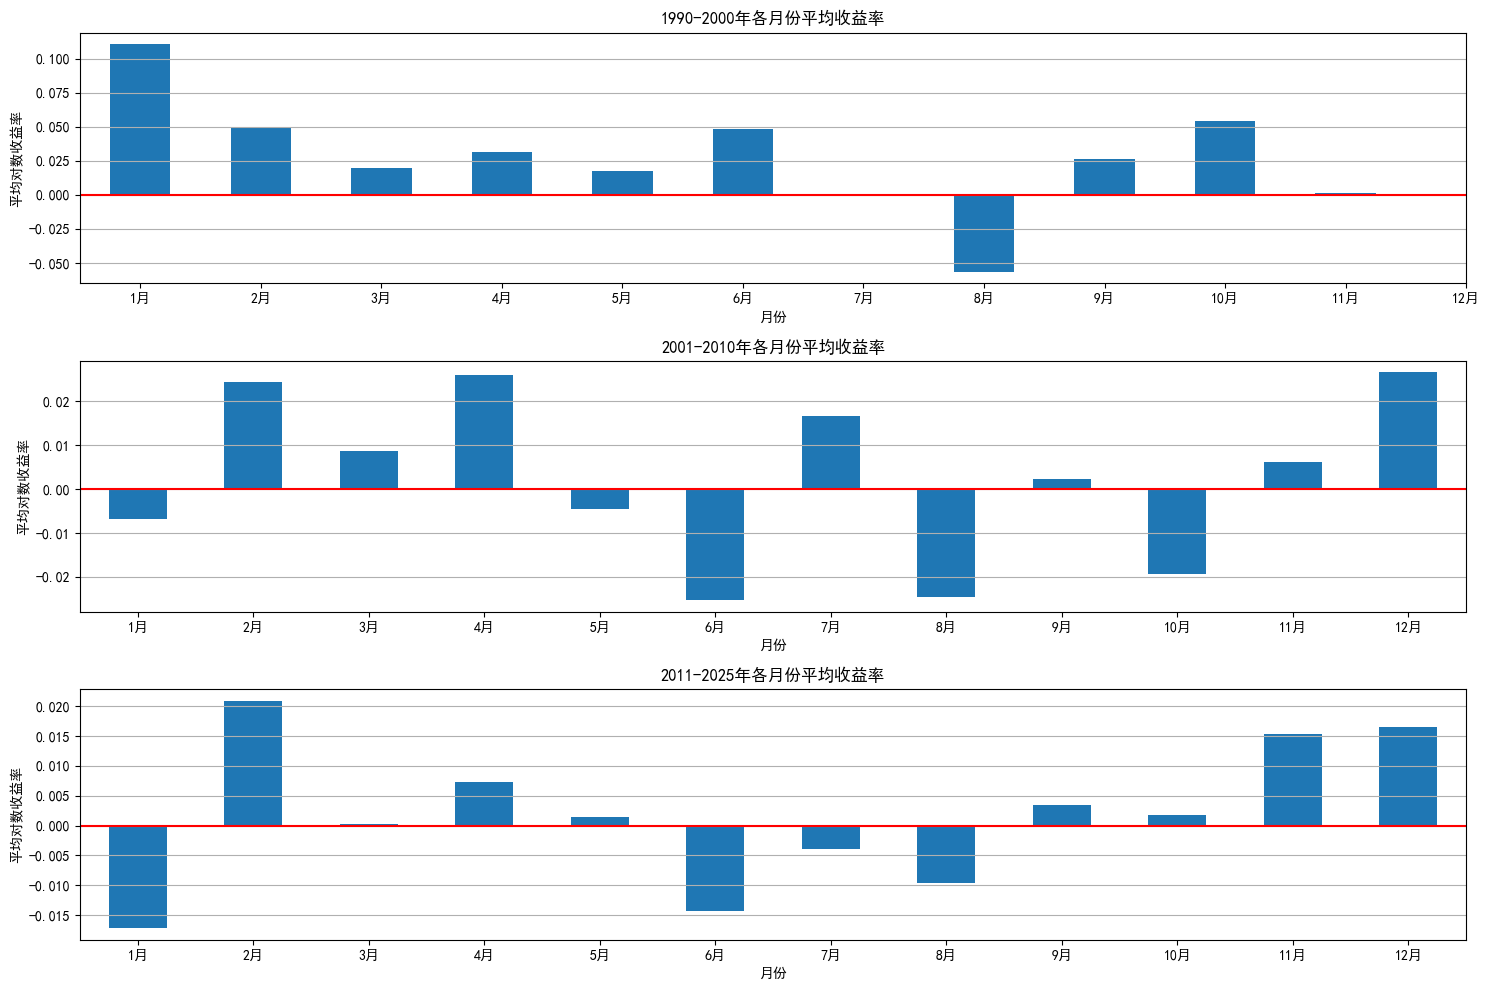


各时期ANOVA检验结果：
1990-2000年：F统计量 = nan, p值 = nan
在5%的显著性水平下，不拒绝原假设，认为该时期各月份收益率不存在显著差异
2001-2010年：F统计量 = 0.4375, p值 = 0.9358
在5%的显著性水平下，不拒绝原假设，认为该时期各月份收益率不存在显著差异
2011-2025年：F统计量 = 0.6681, p值 = 0.7672
在5%的显著性水平下，不拒绝原假设，认为该时期各月份收益率不存在显著差异


e:\Study\2-1\finance_analysis\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\Nanzheng\AppData\Local\Temp\ipykernel_50284\3114764298.py:55: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat1, p_value1 = stats.f_oneway(*months_period1)


In [7]:
# 异质性分析：不同历史时期都存在月度效应吗

# 将数据分为三个时期：1990-2000年、2001-2010年、2011-2025年
period1 = monthly_data['1990':'2000']
period2 = monthly_data['2001':'2010']
period3 = monthly_data['2011':'2025']

# 计算各时期各月份的平均收益率
period1_mean = period1.groupby('month')['log_return'].mean()
period2_mean = period2.groupby('month')['log_return'].mean()
period3_mean = period3.groupby('month')['log_return'].mean()

# 可视化各时期各月份的平均收益率
plt.figure(figsize=(15, 10))

# 第一个时期
plt.subplot(3, 1, 1)
period1_mean.plot(kind='bar')
plt.title('1990-2000年各月份平均收益率')
plt.xlabel('月份')
plt.ylabel('平均对数收益率')
plt.xticks(range(12), ['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月'], rotation=0)
plt.grid(True, axis='y')
plt.axhline(y=0, color='r', linestyle='-')

# 第二个时期
plt.subplot(3, 1, 2)
period2_mean.plot(kind='bar')
plt.title('2001-2010年各月份平均收益率')
plt.xlabel('月份')
plt.ylabel('平均对数收益率')
plt.xticks(range(12), ['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月'], rotation=0)
plt.grid(True, axis='y')
plt.axhline(y=0, color='r', linestyle='-')

# 第三个时期
plt.subplot(3, 1, 3)
period3_mean.plot(kind='bar')
plt.title('2011-2025年各月份平均收益率')
plt.xlabel('月份')
plt.ylabel('平均对数收益率')
plt.xticks(range(12), ['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月'], rotation=0)
plt.grid(True, axis='y')
plt.axhline(y=0, color='r', linestyle='-')

plt.tight_layout()
plt.show()

# 对各时期进行ANOVA检验
print("\n各时期ANOVA检验结果：")

# 1990-2000年
months_period1 = [period1[period1['month'] == i]['log_return'] for i in range(1, 13) if len(period1[period1['month'] == i]) > 0]
if len(months_period1) > 1:
    f_stat1, p_value1 = stats.f_oneway(*months_period1)
    print(f"1990-2000年：F统计量 = {f_stat1:.4f}, p值 = {p_value1:.4f}")
    if p_value1 < 0.05:
        print("在5%的显著性水平下，拒绝原假设，认为该时期各月份收益率存在显著差异")
    else:
        print("在5%的显著性水平下，不拒绝原假设，认为该时期各月份收益率不存在显著差异")

# 2001-2010年
months_period2 = [period2[period2['month'] == i]['log_return'] for i in range(1, 13)]
f_stat2, p_value2 = stats.f_oneway(*months_period2)
print(f"2001-2010年：F统计量 = {f_stat2:.4f}, p值 = {p_value2:.4f}")
if p_value2 < 0.05:
    print("在5%的显著性水平下，拒绝原假设，认为该时期各月份收益率存在显著差异")
else:
    print("在5%的显著性水平下，不拒绝原假设，认为该时期各月份收益率不存在显著差异")

# 2011-2025年
months_period3 = [period3[period3['month'] == i]['log_return'] for i in range(1, 13)]
f_stat3, p_value3 = stats.f_oneway(*months_period3)
print(f"2011-2025年：F统计量 = {f_stat3:.4f}, p值 = {p_value3:.4f}")
if p_value3 < 0.05:
    print("在5%的显著性水平下，拒绝原假设，认为该时期各月份收益率存在显著差异")
else:
    print("在5%的显著性水平下，不拒绝原假设，认为该时期各月份收益率不存在显著差异")

# 解释统计结果，可能的原因

#### 1. 总体分析

In [9]:
print(f"- 样本期间：{monthly_data.index.min().strftime('%Y-%m-%d')} 至 {monthly_data.index.max().strftime('%Y-%m-%d')}")
print(f"- 样本数量：{len(monthly_data)} 个月")
print(f"- 平均月度收益率：{monthly_data['log_return'].mean():.4%}")
print(f"- 月度收益率标准差：{monthly_data['log_return'].std():.4%}")
print(f"- 最高月度收益率：{monthly_data['log_return'].max():.4%}")
print(f"- 最低月度收益率：{monthly_data['log_return'].min():.4%}")


- 样本期间：2000-02-29 至 2025-08-31
- 样本数量：307 个月
- 平均月度收益率：0.2924%
- 月度收益率标准差：7.0007%
- 最高月度收益率：24.2528%
- 最低月度收益率：-28.2783%


#### 2. 月度效应分析

In [12]:
best_month = monthly_mean.idxmax()
worst_month = monthly_mean.idxmin()
print(f"- 表现最好的月份：{best_month}月，平均收益率：{monthly_mean[best_month]:.4%}")
print(f"- 表现最差的月份：{worst_month}月，平均收益率：{monthly_mean[worst_month]:.4%}")

- 表现最好的月份：2月，平均收益率：2.5682%
- 表现最差的月份：6月，平均收益率：-1.7318%


#### 3. 统计检验结果解释

In [14]:
if p_value < 0.05:
    print(f"- ANOVA检验p值为{p_value:.4f}，在5%显著性水平下拒绝原假设，认为中国股市存在显著的月度效应。")
else:
    print(f"- ANOVA检验p值为{p_value:.4f}，在5%显著性水平下不拒绝原假设，认为中国股市不存在显著的月度效应。")

- ANOVA检验p值为0.2097，在5%显著性水平下不拒绝原假设，认为中国股市不存在显著的月度效应。


#### 4. 可能的原因分析

- 投资者情绪：不同月份投资者情绪可能存在差异，如年初效应、年末效应等。
- 政策因素：政府可能在特定月份出台相关政策，影响市场表现。
- 资金面因素：机构投资者的资金配置周期可能影响市场流动性。
- 季节性因素：宏观经济数据的季节性公布可能影响市场预期。


# 总结作业过程遇到的困难以及解决经验
- 在数据处理方面，遇到了日度数据转换为月度数据的问题，通过学习Pandas的resample方法解决了这一问题。
- 在可视化方面，解决了Matplotlib中文显示的问题，通过设置合适的字体参数确保图表中的中文能够正常显示。
- 在统计检验方面，学习了ANOVA检验和t检验的原理和应用，能够正确选择和解释统计检验结果。
- 通过本次作业，我掌握了金融时间序列数据的处理、分析和可视化方法，提高了对金融市场异象的识别能力。
- 体会到了实证研究的严谨性，需要从数据处理、统计检验到结果解释的每个环节都认真对待。